## Подготовка данных

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_error as mae, mean_squared_error as mse, r2_score
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = load_dataset("scikit-learn/auto-mpg")["train"].to_pandas()
df.head()

Generating train split: 100%|██████████| 398/398 [00:00<00:00, 39911.37 examples/s]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB


In [5]:
df.horsepower.unique()

<ArrowStringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
   '?', '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: str

Преобразуем этот столбец в числовой тип

In [6]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df[df.horsepower.isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


Символ "?" был заменен на NaN при приведении столбца к числовому типу

In [7]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Заменим пропуски в столбце 'horsepower' медианой

In [8]:
df['horsepower'] = df['horsepower'].fillna(df.horsepower.median())

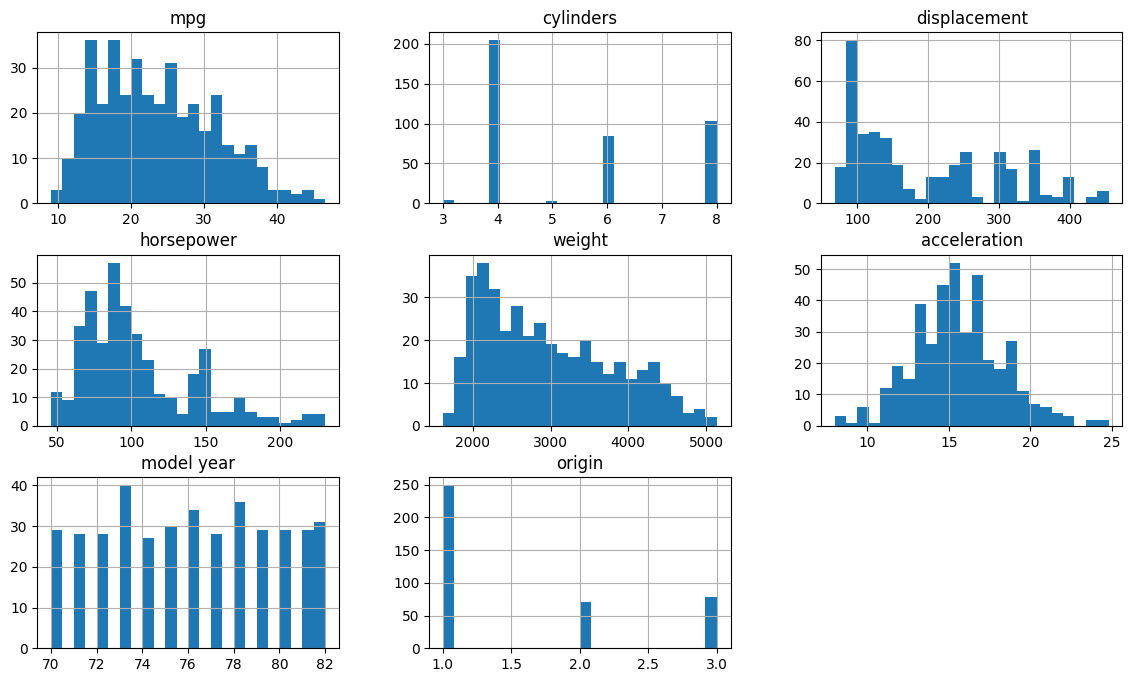

In [9]:
df.hist(figsize=(14, 8), bins=24);

In [10]:
seed = 123

X, y = df.drop(columns='mpg'), df.mpg

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

num_features = X_train.drop(columns='car name').columns
cat_features = ['car name']

preprocessor = ColumnTransformer([
    ('cat_features', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=0.005), cat_features),
    ('num_features', StandardScaler(), num_features)
])

## Построение бейзлайн-моделей

In [11]:
mean_baseline = np.full(len(y_val), y_train.mean())
median_baseline = np.full(len(y_val), y_train.median())

print('Предсказание средним значением:')
print(f'MAE = {mae(y_val, mean_baseline)}, RMSE = {rmse(y_val, mean_baseline)}, R^2 = {r2_score(y_val, mean_baseline)}\n')
print('Предсказание медианой:')
print(f'MAE = {mae(y_val, median_baseline)}, RMSE = {rmse(y_val, median_baseline)}, R^2 = {r2_score(y_val, median_baseline)}')

Предсказание средним значением:
MAE = 5.839831932773109, RMSE = 6.936126401913012, R^2 = -0.0002910742468371641

Предсказание медианой:
MAE = 5.8125, RMSE = 7.0433479255251905, R^2 = -0.03145593642694777


Оба константных предсказателя показывают MAE около 5.8 и RMSE порядка 7, что указывает на довольно крупные средние отклонения и наличие отдельных значительных ошибок. Отрицательные значения R^2 ожидаемы для бейзлайнов: они работают хуже, чем простая модель, возвращающая оптимальную константу. Эти результаты задают базовый уровень качества, относительно которого оцениваются последующие модели.

## Обучение линейной модели

In [12]:
model_mse = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', LinearRegression())
])

model_mse.fit(X_train, y_train)
y_pred = model_mse.predict(X_val)

print(f'MAE = {mae(y_val, y_pred)}\nRMSE = {rmse(y_val, y_pred)}\nR^2 = {r2_score(y_val, y_pred)}')

MAE = 2.4681594424350615
RMSE = 3.243813058694098
R^2 = 0.7812218068761784


/Users/mikhail/hse/ml/env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Линейная регрессия значительно превосходит константные модели: MAE снизилась с ~5.8 до ~2.47, RMSE — с ~7 до ~3.24, а R² вырос с отрицательных значений до 0.78. Это показывает, что модель эффективно использует признаки для предсказания и объясняет большую часть дисперсии целевой переменной, тогда как бейзлайны лишь дают усреднённое приближение.

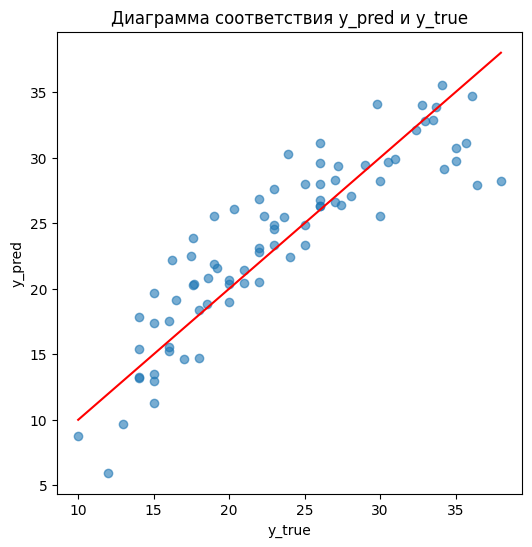

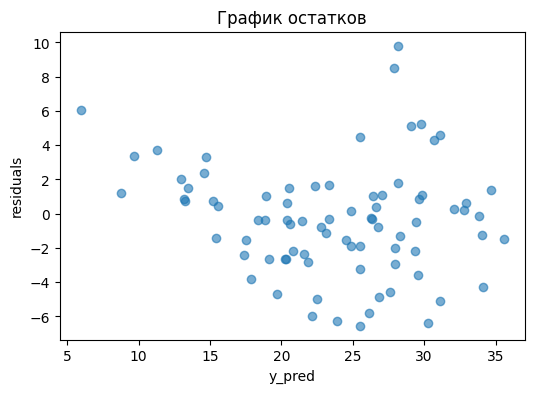

In [13]:
residuals = y_val - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r-')
plt.xlabel('y_true')
plt.ylabel('y_pred')
plt.title('Диаграмма соответствия y_pred и y_true')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.xlabel('y_pred')
plt.ylabel('residuals')
plt.title('График остатков')
plt.show()

Точки на графике y_pred vs y_true в целом лежат близко к линии y=x, однако наблюдается лёгкая дугообразная тенденция, что может указывать на слабую нелинейность зависимости.

На графике остатков заметно, что с ростом предсказанного значения величина ошибок увеличивается, и появляются отдельные выбросы, резко отклоняющиеся от общего распределения. Это может говорить о гетероскедастичности: модель хуже справляется с объектами с более высокими значениями целевой переменной и допускает больший разброс ошибки.

## Сравнение функций потерь

### MAE

Линейная регрессия оптимизирует MSE. Теперь возьмем QuantileRegressor с quantile=0.5, чтобы модель оптимизировала MAE

In [14]:
model_mae = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', QuantileRegressor(quantile=0.5, alpha=0))
])
model_mae.fit(X_train, y_train)
pred_mae = model_mae.predict(X_val)

print(f'MAE = {mae(y_val, pred_mae)}\nRMSE = {rmse(y_val, pred_mae)}\nR^2 = {r2_score(y_val, pred_mae)}')

MAE = 2.3898521677483267
RMSE = 3.341561690939322
R^2 = 0.7678378792691414


/Users/mikhail/hse/ml/env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Теперь проверим функцию потерь 'huber'.

### Huber

In [15]:
from sklearn.linear_model import HuberRegressor
from sklearn.pipeline import Pipeline

model_huber = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', HuberRegressor(epsilon=1.35, alpha=1e-3, max_iter=1000))
])
model_huber.fit(X_train, y_train)
pred_huber = model_huber.predict(X_val)

print(f'MAE = {mae(y_val, pred_huber)}\nRMSE = {rmse(y_val, pred_huber)}\nR^2 = {r2_score(y_val, pred_huber)}')

MAE = 2.349405234587384
RMSE = 3.250593102366546
R^2 = 0.7803062942612935


/Users/mikhail/hse/ml/env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


### Сравнительный анализ результатов

Линейная регрессия - модель с квадратичной ошибкой (MSE) - показывает лучшее качество по RMSE и R^2. Это логично: MSE агрессивно штрафует большие ошибки, поэтому модель сильнее “подгоняется” под редкие крупные отклонения и в среднем предсказывает лучше — если выбросов немного или они неэкстремальные.

Модель с абсолютной функцией потерь (MAE) ведёт себя более устойчиво, но менее точна по RMSE и R^2. Это тоже ожидаемо: MAE не обращает повышенного внимания на крупные ошибки, из-за чего модель получается более “робастной”, но менее гибкой.

Huber занимает промежуточное положение между MSE и MAE. MAE у него лучше чем у других двух моделей, RMSE а R^2 практически совпадает с линейной регрессией. Это означает, что в данных действительно есть выбросы, но их величина умеренная: MSE частично поддаётся их влиянию, но не ломается, а Huber аккуратно сглаживает их воздействие.

## Финальная оценка

В качестве ключевой метрики выбрана RMSE, так как она чувствительна к большим ошибкам и позволяет более строго оценивать качество прогноза. В данной задаче крупные отклонения модели являются нежелательными и искажают интерпретацию результатов больше, чем небольшие ошибки.

В нашем случае модели с функциями MSE и Huber показывают почти одинаковый RMSE, но MAE у Huber заметно ниже. Это говорит о том, что Huber лучше справляется с большинством наблюдений, даже если отдельные ошибки немного выше (что влияет на RMSE).

Таким образом, основной критерий выбора модели – RMSE, чтобы оценивать точность с учётом выбросов, но при сравнении моделей с близким RMSE мы учитываем MAE для понимания устойчивости к выбросам. В нашем примере Huber предпочтительнее, так как она снижает среднюю абсолютную ошибку, сохраняя приемлемый RMSE.

In [16]:
train_pred = model_huber.predict(X_train)
test_pred = model_huber.predict(X_test)

print('Результаты на обучающей выборке:')
print('MAE:', mae(y_train, train_pred))
print('RMSE:', rmse(y_train, train_pred))
print('R^2:', r2_score(y_train, train_pred))

print('\nРезультаты на тестовой выборке:')
print('MAE:', mae(y_test, test_pred))
print('RMSE:', rmse(y_test, test_pred))
print('R^2:', r2_score(y_test, test_pred))

Результаты на обучающей выборке:
MAE: 2.2859095727181327
RMSE: 3.285024993658024
R^2: 0.8289154804852206

Результаты на тестовой выборке:
MAE: 2.7300597855616617
RMSE: 3.4148573422969886
R^2: 0.8250081877304003


/Users/mikhail/hse/ml/env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Сравнение метрик на обучающей и тестовой выборках показывает небольшое увеличение ошибок на тесте (MAE: 2.29 → 2.73, RMSE: 3.29 → 3.41), при этом R² практически не изменилось (0.83 → 0.83). Это свидетельствует о том, что модель устойчива, не переобучена и хорошо обобщает данные на новых наблюдениях. Незначительное ухудшение ошибок на тестовой выборке является естественным и допустимым.